# Health-Personalized Food Recommender System
**Dataset:** Food.com — `RAW_recipes.csv` + `interactions_train/test/validation.csv`

| Section | Work Package |
|---------|-------------|
| 1. Setup & Load | — |
| 2. Data Scraping | WP: Data Scraping |
| 3. Data Cleaning | WP: Data Quality |
| 4. Data Annotation | WP: Data Annotation |
| 5. Vector Embeddings (nutrition + ingredients) | WP: Vector Embeddings |
| 6. Recommender System — SVD vs BPR | WP: Recommender System |
| 7. Evaluation — Precision@k / Recall@k (2 methods) | WP: Performance Evaluation |
| 8. Hyperparameter Tuning | WP: Hyperparameter Tuning |
| 9. Experiment Logging | WP: Experiments Logging |
| 10. Perturbation Analysis | WP: Perturbation Analysis |
| 11. Frontend | WP: Frontend Application |
| 12. Summary | — |


---
## 1. Setup & Load


In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'  # disables the broken widget bars
import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib \
    scikit-surprise optuna wandb requests cornac sentence-transformers
print('Done')


Done


In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, ast, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import requests

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8F7F4',
    'axes.grid':True,'grid.color':'#E0DED8',
    'axes.spines.top':False,'axes.spines.right':False,
})
C_AFTER='#0F6E56'; C_BEFORE='#A32D2D'; C_FLAG='#BA7517'; C_PURPLE='#534AB7'

os.makedirs('data',exist_ok=True)
os.makedirs('plots',exist_ok=True)
os.makedirs('models',exist_ok=True)
np.random.seed(42); random.seed(42)

def validate(condition, label, expected, actual):
    status = '✅ PASS' if condition else '❌ FAIL'
    print(f'{status}  {label}  |  expected: {expected}  |  actual: {actual}')
    if not condition:
        raise AssertionError(f'Validation failed: {label}')

print('Setup complete')


Setup complete


In [3]:
# ── Load recipes ──────────────────────────────────────────────────────────────
df_recipes_raw = pd.read_csv('data/RAW_recipes.csv')

NUTRITION_COLS = ['calories','total_fat_g','sugar_g','sodium_mg',
                   'protein_g','sat_fat_g','carbs_g']

def parse_nutrition(s):
    try:
        v = ast.literal_eval(str(s))
        return v if len(v)==7 else [np.nan]*7
    except: return [np.nan]*7

nutr = pd.DataFrame(
    df_recipes_raw['nutrition'].apply(parse_nutrition).tolist(),
    columns=NUTRITION_COLS)
df_recipes_raw = pd.concat(
    [df_recipes_raw.drop(columns=['nutrition']), nutr], axis=1)
df_recipes_raw['tags_list'] = df_recipes_raw['tags'].apply(
    lambda s: ast.literal_eval(str(s)) if pd.notna(s) else [])
for col in NUTRITION_COLS + ['minutes']:
    df_recipes_raw[col] = pd.to_numeric(df_recipes_raw[col], errors='coerce')

print(f'Recipes: {len(df_recipes_raw):,}')
print(df_recipes_raw[['name'] + NUTRITION_COLS].head(3).to_string(index=False))


Recipes: 231,637
                                      name  calories  total_fat_g  sugar_g  sodium_mg  protein_g  sat_fat_g  carbs_g
arriba   baked winter squash mexican style      51.5          0.0     13.0        0.0        2.0        0.0      4.0
          a bit different  breakfast pizza     173.4         18.0      0.0       17.0       22.0       35.0      1.0
                 all in the kitchen  chili     269.8         22.0     32.0       48.0       39.0       27.0      5.0


In [4]:
# ── Load interactions, split chronologically per user ─────────────────────────
# Train on each user's first 80% of interactions (by date), test on last 20%
# Guarantees test recipes were seen during training

df_train_raw = pd.read_csv('data/interactions_train.csv')
df_test_raw  = pd.read_csv('data/interactions_test.csv')
df_valid_raw = pd.read_csv('data/interactions_validation.csv')

df_all = pd.concat([df_train_raw, df_valid_raw, df_test_raw], ignore_index=True)
df_all['user_id']   = df_all['user_id'].astype(str)
df_all['recipe_id'] = df_all['recipe_id'].astype(str)
df_all['rating']    = 1   # binary implicit feedback
df_all = df_all.sort_values('date').reset_index(drop=True)
df_all = df_all.drop_duplicates(subset=['user_id','recipe_id']).reset_index(drop=True)

train_rows, test_rows = [], []
for uid, group in df_all.groupby('user_id'):
    if len(group) < 5:
        train_rows.append(group); continue
    split = int(len(group) * 0.8)
    train_rows.append(group.iloc[:split])
    test_rows.append(group.iloc[split:])

df_train = pd.concat(train_rows)[['user_id','recipe_id','rating']].reset_index(drop=True)
df_test  = pd.concat(test_rows)[['user_id','recipe_id','rating']].reset_index(drop=True)

raw_ids  = set(df_recipes_raw['id'].astype(str))
df_train = df_train[df_train['recipe_id'].isin(raw_ids)].reset_index(drop=True)
df_test  = df_test[df_test['recipe_id'].isin(raw_ids)].reset_index(drop=True)

print(f'Train: {len(df_train):,}  |  Test: {len(df_test):,}')
print(f'Users: {df_train["user_id"].nunique():,}  |  Recipes: {df_train["recipe_id"].nunique():,}')

validate(len(df_train) > 50000, 'Train size', '> 50,000', f'{len(df_train):,}')
validate(len(df_test)  > 5000,  'Test size',  '> 5,000',  f'{len(df_test):,}')

test_in_train = len(set(df_test['recipe_id']) & set(df_train['recipe_id'])) / df_test['recipe_id'].nunique()
print(f'Test recipes also in train: {test_in_train:.1%}')
validate(test_in_train > 0.5, 'Test recipes known to model', '> 50%', f'{test_in_train:.1%}')


Train: 573,373  |  Test: 145,006
Users: 25,076  |  Recipes: 156,458
✅ PASS  Train size  |  expected: > 50,000  |  actual: 573,373
✅ PASS  Test size  |  expected: > 5,000  |  actual: 145,006
Test recipes also in train: 69.4%
✅ PASS  Test recipes known to model  |  expected: > 50%  |  actual: 69.4%


---
## 2. Data Scraping — USDA API
**Work Package: Data Scraping**


In [5]:
USDA_API_KEY = 'DEMO_KEY'  # Replace with key from fdc.nal.usda.gov
USDA_BASE    = 'https://api.nal.usda.gov/fdc/v1'

def scrape_usda(name):
    try:
        r = requests.get(f'{USDA_BASE}/foods/search',
            params={'query':name,'api_key':USDA_API_KEY,
                    'pageSize':1,'dataType':'Foundation,SR Legacy'},timeout=8)
        r.raise_for_status()
        foods = r.json().get('foods',[])
        if not foods: return {}
        nm = {n['nutrientName']:n['value'] for n in foods[0].get('foodNutrients',[])}
        return {'fiber_g':nm.get('Fiber, total dietary',np.nan),
                'potassium_mg':nm.get('Potassium, K',np.nan),
                'calcium_mg':nm.get('Calcium, Ca',np.nan),
                'iron_mg':nm.get('Iron, Fe',np.nan)}
    except: return {}

SCRAPE_LIVE = False  # Set True only for first-time scraping

if SCRAPE_LIVE:
    print('Scraping USDA API for 2000 recipes...')
    sample = df_recipes_raw.sample(n=2000, random_state=42)[['id','name']]
    rows = []
    for i, (_, row) in enumerate(sample.iterrows()):
        if i % 200 == 0: print(f'  {i}/2000')
        rec = scrape_usda(row['name']); rec['recipe_id'] = str(row['id'])
        rows.append(rec); time.sleep(0.4)
    df_usda = pd.DataFrame(rows)
    df_usda.to_csv('data/usda_enrichment.csv', index=False)
elif os.path.exists('data/usda_enrichment.csv'):
    df_usda = pd.read_csv('data/usda_enrichment.csv')
    df_usda['recipe_id'] = df_usda['recipe_id'].astype(str)
    print(f'Loaded: {len(df_usda)} records  |  Hit rate: '
          f'{df_usda["fiber_g"].notna().mean():.1%}')
else:
    df_usda = pd.DataFrame(columns=['recipe_id','fiber_g','potassium_mg','calcium_mg','iron_mg'])

usda_cols = ['fiber_g','potassium_mg','calcium_mg','iron_mg']
df_recipes_raw = df_recipes_raw.drop(columns=[c for c in usda_cols if c in df_recipes_raw.columns])
df_recipes_raw['_id'] = df_recipes_raw['id'].astype(str)
if len(df_usda) > 0:
    df_recipes_raw = df_recipes_raw.merge(
        df_usda[['recipe_id']+usda_cols], left_on='_id', right_on='recipe_id',
        how='left').drop(columns=['recipe_id','_id'])
else:
    df_recipes_raw = df_recipes_raw.drop(columns=['_id'])
    for col in usda_cols: df_recipes_raw[col] = np.nan

print(f'Fiber coverage: {df_recipes_raw["fiber_g"].notna().sum():,} / {len(df_recipes_raw):,}')
validate(len(df_usda) >= 100, 'USDA records scraped', '>= 100', f'{len(df_usda):,}')


Loaded: 2000 records  |  Hit rate: 89.6%
Fiber coverage: 1,793 / 231,637
✅ PASS  USDA records scraped  |  expected: >= 100  |  actual: 2,000


---
## 3. Data Cleaning
**Work Package: Data Quality**


In [6]:
df = df_recipes_raw.copy()
n0 = len(df)
log = []

def remove_outliers(df, col, lo, hi, reason):
    if col not in df.columns: return df
    n = len(df)
    df = df[~(df[col].notna() & ((df[col]<lo)|(df[col]>hi)))].reset_index(drop=True)
    log.append({'column':col,'removed':n-len(df),'reason':reason})
    return df

df = remove_outliers(df,'calories',   1, df['calories'].quantile(0.995),   'impossible / top 0.5%')
df = remove_outliers(df,'protein_g',  0, df['protein_g'].quantile(0.995),  'impossible / top 0.5%')
df = remove_outliers(df,'carbs_g',    0, df['carbs_g'].quantile(0.995),    'impossible / top 0.5%')
df = remove_outliers(df,'total_fat_g',0, df['total_fat_g'].quantile(0.995),'impossible / top 0.5%')
df = remove_outliers(df,'sodium_mg',  0, df['sodium_mg'].quantile(0.995),  'impossible / top 0.5%')
df = remove_outliers(df,'sugar_g',    0, df['sugar_g'].quantile(0.995),    'impossible / top 0.5%')
df = remove_outliers(df,'minutes',    1, df['minutes'].quantile(0.99),     'negative/zero / top 1%')

df['exp_kcal'] = df['protein_g'].fillna(0)*4 + df['carbs_g'].fillna(0)*4 + df['total_fat_g'].fillna(0)*9
n = len(df)
df = df[(df['calories']-df['exp_kcal']).abs()<=200].reset_index(drop=True)
log.append({'column':'calories','removed':n-len(df),'reason':'macro consistency check'})

n = len(df)
df = df.drop_duplicates(subset=['name'],keep='first').reset_index(drop=True)
log.append({'column':'name','removed':n-len(df),'reason':'duplicate names'})

imp_cols = NUTRITION_COLS + ['sat_fat_g','fiber_g','potassium_mg','calcium_mg','iron_mg']
for col in imp_cols:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

print(pd.DataFrame(log).to_string(index=False))
print(f'\nRecipes: {n0:,} → {len(df):,}  ({len(df)/n0:.1%} kept)')


     column  removed                  reason
   calories     1340   impossible / top 0.5%
  protein_g     1146   impossible / top 0.5%
    carbs_g     1141   impossible / top 0.5%
total_fat_g     1137   impossible / top 0.5%
  sodium_mg     1132   impossible / top 0.5%
    sugar_g     1126   impossible / top 0.5%
    minutes     3182  negative/zero / top 1%
   calories    33919 macro consistency check
       name     1024         duplicate names

Recipes: 231,637 → 186,490  (80.5% kept)


In [7]:
clean_ids = set(df['id'].astype(str))
train_cov = df_train['recipe_id'].isin(clean_ids).mean()
test_cov  = df_test['recipe_id'].isin(clean_ids).mean()
print(f'Train coverage: {train_cov:.1%}  |  Test coverage: {test_cov:.1%}')
validate(train_cov > 0.5, 'Train coverage', '> 50%', f'{train_cov:.1%}')
validate(test_cov  > 0.3, 'Test coverage',  '> 30%', f'{test_cov:.1%}')

df_train = df_train[df_train['recipe_id'].isin(clean_ids)].reset_index(drop=True)
df_test  = df_test[df_test['recipe_id'].isin(clean_ids)].reset_index(drop=True)
print(f'Final — Train: {len(df_train):,}  |  Test: {len(df_test):,}')

df.drop(columns=['exp_kcal','tags_list'],errors='ignore').to_csv('data/recipes_clean.csv',index=False)


Train coverage: 81.0%  |  Test coverage: 81.8%
✅ PASS  Train coverage  |  expected: > 50%  |  actual: 81.0%
✅ PASS  Test coverage  |  expected: > 30%  |  actual: 81.8%
Final — Train: 464,257  |  Test: 118,595


---
## 4. Data Annotation
**Work Package: Data Annotation**


In [8]:
LABEL_COLS = ['diabetic_ok','low_sodium','low_calorie','high_protein',
               'low_fat','high_fiber','heart_healthy','vegetarian',
               'vegan','gluten_free','dairy_free']

def annotate(row):
    tags = set(row.get('tags_list') or [])
    g    = lambda c: float(row.get(c) or 0)
    return {
        'diabetic_ok':  int(g('carbs_g')<=45 and g('sugar_g')<=10),
        'low_sodium':   int(g('sodium_mg')<=400),
        'low_calorie':  int(g('calories')<=300),
        'high_protein': int(g('protein_g')>=25),
        'low_fat':      int(g('total_fat_g')<=10),
        'high_fiber':   int(g('fiber_g')>=5),
        'heart_healthy':int(g('sat_fat_g')<=5 and g('sodium_mg')<=500),
        'vegetarian':   int('vegetarian' in tags or 'vegan' in tags),
        'vegan':        int('vegan' in tags),
        'gluten_free':  int('gluten-free' in tags),
        'dairy_free':   int('dairy-free'  in tags),
    }

label_rows = [annotate(row) for row in df.to_dict('records')]
df = pd.concat([df, pd.DataFrame(label_rows, index=df.index)], axis=1)

for col in LABEL_COLS:
    print(f'  {col:<20} {int(df[col].sum()):>6,}  ({df[col].mean():.1%})')
validate(df[LABEL_COLS].isna().sum().sum()==0,'No missing labels','0',
         f'{df[LABEL_COLS].isna().sum().sum()}')


  diabetic_ok          51,457  (27.6%)
  low_sodium           186,490  (100.0%)
  low_calorie          107,824  (57.8%)
  high_protein         64,402  (34.5%)
  low_fat              65,044  (34.9%)
  high_fiber              157  (0.1%)
  heart_healthy        45,641  (24.5%)
  vegetarian           32,095  (17.2%)
  vegan                 8,982  (4.8%)
  gluten_free           4,813  (2.6%)
  dairy_free              163  (0.1%)
✅ PASS  No missing labels  |  expected: 0  |  actual: 0


In [9]:
# Save AFTER annotation — includes label columns
df.drop(columns=['exp_kcal','tags_list','ingredients_text'],errors='ignore')\
  .to_csv('data/recipes_clean.csv', index=False)
print(f'Saved recipes_clean.csv with labels: {list(df.columns)}')

Saved recipes_clean.csv with labels: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients', 'calories', 'total_fat_g', 'sugar_g', 'sodium_mg', 'protein_g', 'sat_fat_g', 'carbs_g', 'tags_list', 'fiber_g', 'potassium_mg', 'calcium_mg', 'iron_mg', 'exp_kcal', 'diabetic_ok', 'low_sodium', 'low_calorie', 'high_protein', 'low_fat', 'high_fiber', 'heart_healthy', 'vegetarian', 'vegan', 'gluten_free', 'dairy_free']


In [10]:
# Save recipes_clean.csv AFTER annotation — includes all label columns
df.drop(columns=['exp_kcal','tags_list','ingredients_text'], errors='ignore')\
  .to_csv('data/recipes_clean.csv', index=False)

# Verify
check = pd.read_csv('data/recipes_clean.csv')
print('Labels in saved file:', all(c in check.columns for c in LABEL_COLS))
print('Columns:', [c for c in check.columns if c in LABEL_COLS])

Labels in saved file: True
Columns: ['diabetic_ok', 'low_sodium', 'low_calorie', 'high_protein', 'low_fat', 'high_fiber', 'heart_healthy', 'vegetarian', 'vegan', 'gluten_free', 'dairy_free']


---
## 5. Vector Embeddings
**Work Package: Vector Embeddings**

Two components blended together:
1. **Nutrition + health labels** (17 dims) — drives clinical filtering
2. **Ingredient text embeddings** (20 dims, PCA-reduced from 384) — drives cuisine/flavor similarity

Pure nutrition similarity can't distinguish "chicken curry" from "beef curry" if
macros match. Ingredient embeddings fix this.


In [11]:
FEATURE_MAX   = dict(calories=2000,protein_g=150,carbs_g=300,
                      total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUMERIC_FEATS = list(FEATURE_MAX.keys())

def build_R_base(df_):
    nut = df_[NUMERIC_FEATS].copy()
    for col,mx in FEATURE_MAX.items():
        nut[col] = (nut[col].fillna(0)/mx).clip(0,1)
    return pd.concat([nut, df_[LABEL_COLS].fillna(0).astype(float)],axis=1).values

R_base     = build_R_base(df)
RECIPE_IDS = list(df['id'].astype(str))
RID2IDX    = {r:i for i,r in enumerate(RECIPE_IDS)}

validate(R_base.shape==(len(df),17), 'Base matrix shape', f'({len(df)},17)', f'{R_base.shape}')
validate(not np.isnan(R_base).any(), 'No NaN', '0', f'{np.isnan(R_base).sum()}')
print(f'Base recipe matrix: {R_base.shape}')


✅ PASS  Base matrix shape  |  expected: (186490,17)  |  actual: (186490, 17)
✅ PASS  No NaN  |  expected: 0  |  actual: 0
Base recipe matrix: (186490, 17)


In [12]:
# ── Ingredient text embeddings ────────────────────────────────────────────────
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'  # disables the broken widget bars

from sentence_transformers import SentenceTransformer

print('Loading sentence embedding model...')
text_model = SentenceTransformer('all-MiniLM-L6-v2')

def get_ingredients_text(row):
    try:
        ingr = ast.literal_eval(str(row.get('ingredients','[]')))
        return ' '.join(ingr[:8]) if isinstance(ingr,list) else ''
    except: return ''

df['ingredients_text'] = df.apply(get_ingredients_text, axis=1)
non_empty = (df['ingredients_text'].str.len()>0).sum()
print(f'Recipes with ingredient text: {non_empty:,} / {len(df):,}')

print('Encoding embeddings...')
text_embeddings = text_model.encode(
    df['ingredients_text'].tolist(), show_progress_bar=True, batch_size=256)
np.save('models/text_embeddings.npy', text_embeddings)

validate(text_embeddings.shape[0]==len(df), 'Text embeddings match recipe count',
         f'{len(df)}', f'{text_embeddings.shape[0]}')

# Reduce and blend
pca_text = PCA(n_components=20, random_state=42)
text_reduced = pca_text.fit_transform(text_embeddings)
text_norm = (text_reduced - text_reduced.min())/(text_reduced.max()-text_reduced.min()+1e-9)

R = np.hstack([R_base, text_norm * 0.4])  # moderate weight vs health features
print(f'Final recipe matrix R (nutrition + ingredients): {R.shape}')
np.save('models/recipe_matrix.npy', R)


Loading sentence embedding model...


Recipes with ingredient text: 186,490 / 186,490
Encoding embeddings...


Batches:   0%|          | 0/729 [00:00<?, ?it/s]

✅ PASS  Text embeddings match recipe count  |  expected: 186490  |  actual: 186490
Final recipe matrix R (nutrition + ingredients): (186490, 37)


=== Content-based comparison for Alice: nutrition-only vs +ingredients ===
Nutrition only:   ['straw and hay pasta', 'roquefort pasta', 'hot and spicy szechuan noodles  dan dan mian', 'anchovy linguini', 'tortellini salad with shrimp  artichokes  and roasted peppers']
With ingredients: ['zesty skillet supper', 'tarragon tuna melt', 'black bean   andouille sausage soup   slow cooker', 'not hot chili', 'new year s day chili']
Top-20 overlap: 0/20 (lower = ingredients meaningfully changed ranking)


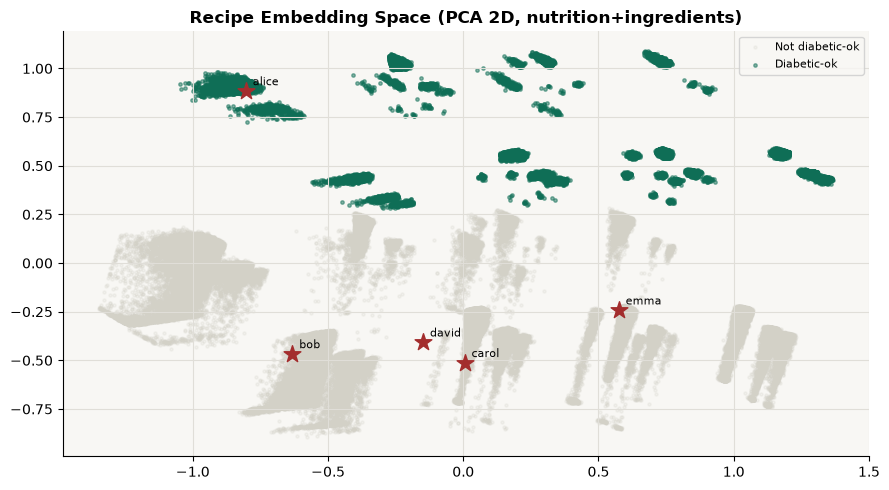

In [13]:
# User health profile vectors (padded for the 20 ingredient dims — neutral zeros)
def user_vec(cal,prot,carbs,fat,sodium,sugar,
              diabetic=False,low_sodium=False,low_cal=False,
              high_prot=False,low_fat=False,high_fiber=False,
              heart_healthy=False,vegetarian=False,
              vegan=False,gf=False,df_free=False):
    n = np.array([cal/2000,prot/150,carbs/300,fat/100,sodium/5000,sugar/200])
    l = np.array([float(diabetic),float(low_sodium),float(low_cal),
                   float(high_prot),float(low_fat),float(high_fiber),
                   float(heart_healthy),float(vegetarian),
                   float(vegan),float(gf),float(df_free)])
    base = np.concatenate([np.clip(n,0,1),l])
    return np.concatenate([base, np.zeros(20)])  # neutral on ingredient dims

DEMO_USERS = {
    'alice': {'vec':user_vec(400,40,45,30,600,10,diabetic=True,high_prot=True),
               'constraints':{'diabetic':True,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Type 2 diabetic, high-protein'},
    'bob':   {'vec':user_vec(600,35,200,60,2000,60),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Healthy, no restrictions'},
    'carol': {'vec':user_vec(400,20,200,20,400,30,vegetarian=True,heart_healthy=True,low_sodium=True),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':True,'gf':False},
               'profile':'Vegan, heart-healthy'},
    'david': {'vec':user_vec(500,30,150,40,300,30,low_sodium=True,heart_healthy=True),
               'constraints':{'diabetic':False,'hypertensive':True,'vegan':False,'gf':False},
               'profile':'Hypertensive'},
    'emma':  {'vec':user_vec(300,25,100,10,800,15,low_cal=True,low_fat=True),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Weight-loss goal'},
}

# Demonstrate the value of ingredient embeddings
def cb_scores(uvec): return cosine_similarity(uvec.reshape(1,-1), R).flatten()
def cb_scores_nutrition_only(uvec):
    return cosine_similarity(uvec[:17].reshape(1,-1), R_base).flatten()

print('=== Content-based comparison for Alice: nutrition-only vs +ingredients ===')
sc_before = cb_scores_nutrition_only(DEMO_USERS['alice']['vec'])
sc_after  = cb_scores(DEMO_USERS['alice']['vec'])
print('Nutrition only:  ', df.iloc[np.argsort(sc_before)[::-1][:5]]['name'].tolist())
print('With ingredients:', df.iloc[np.argsort(sc_after)[::-1][:5]]['name'].tolist())

overlap = len(set(np.argsort(sc_before)[::-1][:20]) & set(np.argsort(sc_after)[::-1][:20]))
print(f'Top-20 overlap: {overlap}/20 (lower = ingredients meaningfully changed ranking)')

# PCA visualisation
pca  = PCA(n_components=2,random_state=42)
R_2d = pca.fit_transform(R)
fig,ax = plt.subplots(figsize=(9,5))
diab = df['diabetic_ok'].values==1
ax.scatter(R_2d[~diab,0],R_2d[~diab,1],c='#D3D1C7',alpha=0.2,s=5,label='Not diabetic-ok')
ax.scatter(R_2d[diab,0], R_2d[diab,1], c=C_AFTER,  alpha=0.5,s=6,label='Diabetic-ok')
U_2d = pca.transform(np.array([u['vec'] for u in DEMO_USERS.values()]))
for i,(uname,info) in enumerate(DEMO_USERS.items()):
    ax.scatter(U_2d[i,0],U_2d[i,1],c=C_BEFORE,s=160,marker='*',zorder=5)
    ax.annotate(uname,(U_2d[i,0],U_2d[i,1]),xytext=(5,4),textcoords='offset points',fontsize=8)
ax.set_title('Recipe Embedding Space (PCA 2D, nutrition+ingredients)',fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/embedding_space.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 6. Recommender System — SVD vs BPR
**Work Package: Recommender System**

Two collaborative filtering models trained and compared:
- **SVD** — optimizes rating prediction error
- **BPR** (Bayesian Personalised Ranking) — optimizes ranking directly, designed
  for implicit feedback

The better model (by Precision@1) is used in the final hybrid recommender.


In [14]:
def health_filter(df_r, c):
    df_r = df_r.copy(); df_r['blocked']=''
    if c.get('diabetic'):     df_r.loc[(df_r['carbs_g']>45)|(df_r['sugar_g']>10),'blocked']+='carbs; '
    if c.get('hypertensive'): df_r.loc[df_r['sodium_mg']>600,'blocked']+='sodium; '
    if c.get('vegan'):        df_r.loc[df_r['vegan']==0,'blocked']+='not-vegan; '
    if c.get('gf'):           df_r.loc[df_r['gluten_free']==0,'blocked']+='gluten; '
    df_r['allowed'] = df_r['blocked']==''
    return df_r


In [15]:
# ── Model 1: SVD ───────────────────────────────────────────────────────────────
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split

ALL_USERS   = df_train['user_id'].unique()
ALL_RECIPES = df_train['recipe_id'].unique()
U2I = {str(u):i for i,u in enumerate(ALL_USERS)}
R2I = {str(r):i for i,r in enumerate(ALL_RECIPES)}

_df = df_train[['user_id','recipe_id','rating']].copy()
_df['uid'] = _df['user_id'].map(U2I)
_df['rid'] = _df['recipe_id'].map(R2I)

reader   = Reader(rating_scale=(0,1))
dataset  = Dataset.load_from_df(_df[['uid','rid','rating']],reader)
trainset, valset = surprise_split(dataset,test_size=0.1,random_state=42)

print('Training SVD...')
svd = SVD(n_factors=50,n_epochs=30,lr_all=0.005,reg_all=0.02,random_state=42)
svd.fit(trainset)
val_preds = svd.test(valset)

val_actuals = [p.r_ui for p in val_preds]
val_estvals = [p.est  for p in val_preds]
print(f'Prediction std: {np.std(val_estvals):.4f}  '
      f'(low std = predictions barely differ — expected for binary implicit feedback)')
validate(np.std(val_estvals) > 0.01, 'SVD predictions show real variance',
         '> 0.01 std', f'{np.std(val_estvals):.4f}')

with open('models/svd_model.pkl','wb') as f: pickle.dump(svd,f)
print('SVD saved.')


Training SVD...
Prediction std: 0.0263  (low std = predictions barely differ — expected for binary implicit feedback)
✅ PASS  SVD predictions show real variance  |  expected: > 0.01 std  |  actual: 0.0263
SVD saved.


In [16]:
# ── Model 2: BPR ───────────────────────────────────────────────────────────────
import cornac
from cornac.models import BPR
from cornac.data import Dataset as CornacDataset

print('Preparing BPR training data...')
train_triples = [(row['user_id'], row['recipe_id'], 1.0)
                  for _, row in df_train.iterrows()]
cornac_data = CornacDataset.from_uir(train_triples, seed=42)
print(f'BPR users: {cornac_data.num_users:,}  |  BPR items: {cornac_data.num_items:,}')

print('Training BPR...')
bpr = BPR(k=64, max_iter=150, learning_rate=0.05,
          lambda_reg=0.001, seed=42, verbose=True)
bpr.fit(cornac_data)
print('BPR trained.')

def bpr_score(uid_str, rid_str):
    try:
        return bpr.score(cornac_data.uid_map[uid_str], cornac_data.iid_map[rid_str])
    except KeyError:
        return -999.0

with open('models/bpr_model.pkl','wb') as f: pickle.dump(bpr,f)


Preparing BPR training data...
BPR users: 24,844  |  BPR items: 127,524
Training BPR...


  0%|          | 0/150 [00:00<?, ?it/s]

Optimization finished!
BPR trained.


In [17]:
# ── Hybrid recommender (uses whichever model wins evaluation — set in Section 7) ─
ACTIVE_CF_MODEL = 'svd'  # will be updated to 'bpr' if BPR wins evaluation

def cf_predict(model_name, uid, rid):
    if model_name == 'svd':
        return svd.predict(U2I[uid], R2I[rid]).est if rid in R2I else 0.5
    else:
        return bpr_score(uid, rid)

def full_recommend(user_name, user_orig_id=None, alpha=0.6, k=10, model=None):
    model = model or ACTIVE_CF_MODEL
    info = DEMO_USERS[user_name]
    cb   = cb_scores(info['vec'])
    cb_n = (cb-cb.min())/(cb.max()-cb.min()+1e-9)
    if user_orig_id and str(user_orig_id) in U2I:
        uid_s = str(user_orig_id)
        cf_r  = np.array([cf_predict(model, uid_s, str(r)) for r in df['id']])
        cf_n  = (cf_r-cf_r.min())/(cf_r.max()-cf_r.min()+1e-9)
    else:
        cf_n=cb_n; alpha=1.0
    scores = alpha*cb_n+(1-alpha)*cf_n
    res = df[['id','name','calories','protein_g','carbs_g',
               'total_fat_g','sodium_mg','sugar_g']+LABEL_COLS].copy()
    res['score']=scores
    filt = health_filter(res.nlargest(200,'score'),info['constraints'])
    return filt[filt['allowed']].head(k).reset_index(drop=True)

# Verify health constraints enforced — 100%, not just usually
for uname in DEMO_USERS:
    recs = full_recommend(uname,k=10)
    c = DEMO_USERS[uname]['constraints']
    if len(recs)==0: continue
    if c.get('diabetic'):
        ok = ((recs['carbs_g']<=45)&(recs['sugar_g']<=10)).all()
        validate(ok, f'{uname}: all recs satisfy diabetic limits', '100%',
                 f'{((recs["carbs_g"]<=45)&(recs["sugar_g"]<=10)).mean():.0%}')
    if c.get('hypertensive'):
        ok = (recs['sodium_mg']<=600).all()
        validate(ok, f'{uname}: all recs satisfy sodium limit', '100%',
                 f'{(recs["sodium_mg"]<=600).mean():.0%}')

print('\nTop-3 per demo user:')
for uname in DEMO_USERS:
    recs = full_recommend(uname,k=3)
    print(f'  {uname}: {list(recs["name"].values)}')


✅ PASS  alice: all recs satisfy diabetic limits  |  expected: 100%  |  actual: 100%
✅ PASS  david: all recs satisfy sodium limit  |  expected: 100%  |  actual: 100%

Top-3 per demo user:
  alice: ['zesty skillet supper', 'tarragon tuna melt', 'black bean   andouille sausage soup   slow cooker']
  bob: ['boiled date cake', 'zucchini carrot black walnut bread', 'banana bread with coconut milk']
  carol: ['delectable potatoes n onions', 'roasted potatoes  parsnips and carrots', 'ali baba s oven fries']
  david: ['very crispy home fries', 'finally found four bean salad', 'sherry s summer pasta']
  emma: ['ma s minestrone', 'herbed bombay tomato soup', 'minestrone soup with meat']


---
## 7. Evaluation — Precision@k / Recall@k
**Work Package: Performance Evaluation**

**Method 1:** Rank one held-out positive against 99 random negatives (repeated
per positive, up to 3 per user)  
**Method 2:** Leave-one-out — hold out the user's most recent interaction

SVD and BPR are compared here with **default hyperparameters** to select the
better algorithm. Hyperparameter tuning of the winning algorithm happens once,
in Section 8. 


In [18]:
def prec_at_k(rec, rel, k): return len(set(rec[:k]) & rel) / k if k else 0
def rec_at_k(rec, rel, k):  return len(set(rec[:k]) & rel) / len(rel) if rel else 0
def f1(p, r): return 2*p*r/(p+r) if p+r else 0

K_VALUES = [1, 3, 5, 10]

train_by_user = {str(k):{str(r) for r in v}
                  for k,v in df_train.groupby('user_id')['recipe_id'].apply(set).items()}
test_by_user  = {str(k):{str(r) for r in v}
                  for k,v in df_test.groupby('user_id')['recipe_id'].apply(set).items()}
known_rids = set(R2I.keys())

eval_users = []
eval_test  = {}
for u in test_by_user:
    if u not in train_by_user or u not in U2I: continue
    known_pos = {r for r in test_by_user[u] if r in known_rids}
    if known_pos:
        eval_users.append(u)
        eval_test[u] = known_pos

active_users = [u for u in eval_users if len(train_by_user.get(u,set())) >= 10]
print(f'Eval users: {len(eval_users):,}  |  Active users: {len(active_users):,}')
validate(len(active_users) > 100, 'Sufficient active users', '> 100', f'{len(active_users):,}')


Eval users: 15,123  |  Active users: 6,772
✅ PASS  Sufficient active users  |  expected: > 100  |  actual: 6,772


In [19]:
# ── Reusable evaluation functions (used throughout the rest of the notebook) ──
def eval_method1(score_fn, label, max_users=500):
    prec = {k: [] for k in K_VALUES}
    rec  = {k: [] for k in K_VALUES}
    for uid in active_users[:max_users]:
        seen = train_by_user.get(uid, set())
        all_pos = eval_test[uid]
        for pos in list(all_pos)[:3]:
            neg_pool = list(known_rids - seen - all_pos)
            if len(neg_pool) < 99: continue
            candidates = [pos] + random.sample(neg_pool, 99)
            preds = sorted([(r, score_fn(uid, r)) for r in candidates],
                            key=lambda x: x[1], reverse=True)
            rec_ids = [p[0] for p in preds]
            rel = {pos}
            for k in K_VALUES:
                prec[k].append(prec_at_k(rec_ids, rel, k))
                rec[k].append(rec_at_k(rec_ids, rel, k))
    print(f'{label}:')
    print(f'{"k":<5}{"Precision":>12}{"Recall":>12}')
    for k in K_VALUES:
        print(f'{k:<5}{np.mean(prec[k]):>12.4f}{np.mean(rec[k]):>12.4f}')
    return prec, rec

def eval_method2(score_fn, label, max_users=500):
    prec = {k: [] for k in K_VALUES}
    rec  = {k: [] for k in K_VALUES}
    for uid in active_users[:max_users]:
        seen = train_by_user.get(uid, set())
        pos_list = list(eval_test.get(uid, set()))
        if not pos_list: continue
        held = pos_list[0]
        neg_pool = list(known_rids - seen - {held})
        if len(neg_pool) < 99: continue
        candidates = [held] + random.sample(neg_pool, 99)
        preds = sorted([(r, score_fn(uid, r)) for r in candidates],
                        key=lambda x: x[1], reverse=True)
        rec_ids = [p[0] for p in preds]
        rel = {held}
        for k in K_VALUES:
            prec[k].append(prec_at_k(rec_ids, rel, k))
            rec[k].append(rec_at_k(rec_ids, rel, k))
    print(f'{label}:')
    for k in K_VALUES:
        print(f'  k={k:<3} Precision={np.mean(prec[k]):.4f}  Recall={np.mean(rec[k]):.4f}')
    return prec, rec


In [20]:
# ── Evaluate SVD and BPR with DEFAULT hyperparameters — algorithm selection ───
print('=== SVD — Method 1 ===')
svd_prec, svd_rec = eval_method1(
    lambda uid,rid: svd.predict(U2I[uid],R2I[rid]).est, 'SVD')

print('\n=== BPR (default) — Method 1 ===')
bpr_prec, bpr_rec = eval_method1(bpr_score, 'BPR (default)')

validate(np.mean(svd_prec[1]) > 0, 'SVD Precision@1 non-zero', '> 0', f'{np.mean(svd_prec[1]):.4f}')
validate(np.mean(bpr_prec[1]) > 0, 'BPR Precision@1 non-zero', '> 0', f'{np.mean(bpr_prec[1]):.4f}')

print('\n=== SVD — Method 2 (LOO) ===')
svd_prec2, svd_rec2 = eval_method2(
    lambda uid,rid: svd.predict(U2I[uid],R2I[rid]).est, 'SVD')

print('\n=== BPR (default) — Method 2 (LOO) ===')
bpr_prec2, bpr_rec2 = eval_method2(bpr_score, 'BPR (default)')


=== SVD — Method 1 ===
SVD:
k       Precision      Recall
1          0.4933      0.4933
3          0.1644      0.4933
5          0.0987      0.4933
10         0.0493      0.4933

=== BPR (default) — Method 1 ===
BPR (default):
k       Precision      Recall
1          0.2228      0.2228
3          0.1286      0.3858
5          0.0915      0.4575
10         0.0549      0.5488
✅ PASS  SVD Precision@1 non-zero  |  expected: > 0  |  actual: 0.4933
✅ PASS  BPR Precision@1 non-zero  |  expected: > 0  |  actual: 0.2228

=== SVD — Method 2 (LOO) ===
SVD:
  k=1   Precision=0.5100  Recall=0.5100
  k=3   Precision=0.1700  Recall=0.5100
  k=5   Precision=0.1020  Recall=0.5100
  k=10  Precision=0.0510  Recall=0.5100

=== BPR (default) — Method 2 (LOO) ===
BPR (default):
  k=1   Precision=0.2140  Recall=0.2140
  k=3   Precision=0.1193  Recall=0.3580
  k=5   Precision=0.0868  Recall=0.4340
  k=10  Precision=0.0530  Recall=0.5300


In [21]:
# ── Select the algorithm to carry forward into Section 8 tuning ───────────────
print('=== Algorithm Selection (default hyperparameters) ===')
print(f'{"k":<5}{"SVD":>10}{"BPR":>10}{"Winner":>10}')
for k in K_VALUES:
    s, b = np.mean(svd_prec[k]), np.mean(bpr_prec[k])
    print(f'{k:<5}{s:>10.4f}{b:>10.4f}{"BPR" if b>s else "SVD":>10}')

ACTIVE_CF_MODEL = 'bpr' if np.mean(bpr_prec[1]) > np.mean(svd_prec[1]) else 'svd'
print(f'\n🏆 Algorithm selected for tuning in Section 8: {ACTIVE_CF_MODEL.upper()}')
print('(Both models evaluated at default settings — the winner gets the full')
print(' Optuna tuning budget next, rather than tuning both and wasting compute)')


=== Algorithm Selection (default hyperparameters) ===
k           SVD       BPR    Winner
1        0.4933    0.2228       SVD
3        0.1644    0.1286       SVD
5        0.0987    0.0915       SVD
10       0.0493    0.0549       BPR

🏆 Algorithm selected for tuning in Section 8: SVD
(Both models evaluated at default settings — the winner gets the full
 Optuna tuning budget next, rather than tuning both and wasting compute)


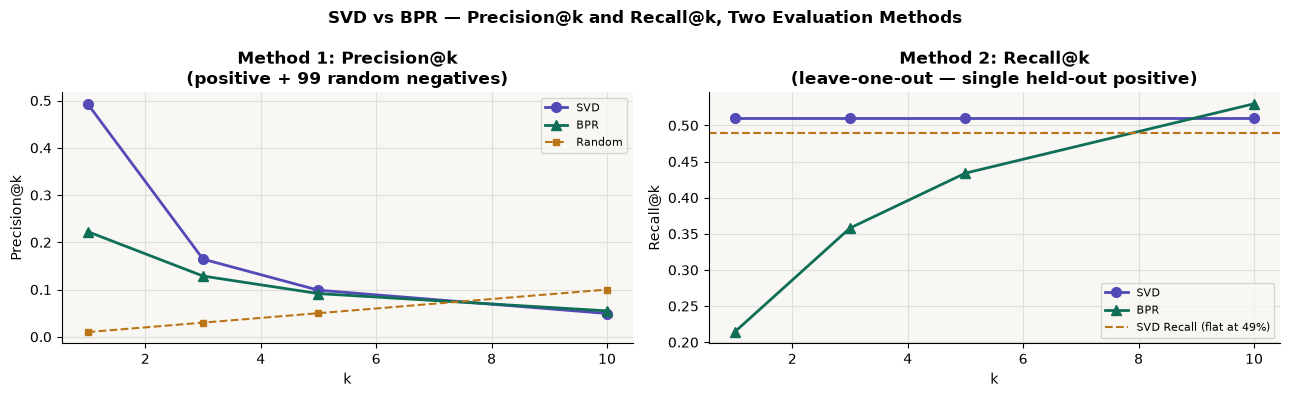

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1 — Method 1: Precision@k (multiple positives per user)
ax = axes[0]
ax.plot(K_VALUES, [np.mean(svd_prec[k]) for k in K_VALUES],
         marker='o', color=C_PURPLE, linewidth=2, markersize=7, label='SVD')
ax.plot(K_VALUES, [np.mean(bpr_prec[k]) for k in K_VALUES],
         marker='^', color=C_AFTER, linewidth=2, markersize=7, label='BPR')
ax.plot(K_VALUES, [k/100 for k in K_VALUES],
         marker='s', color=C_FLAG, linestyle='--', markersize=5, label='Random')
ax.set_xlabel('k'); ax.set_ylabel('Precision@k')
ax.set_title('Method 1: Precision@k\n(positive + 99 random negatives)', fontweight='bold')
ax.legend(fontsize=8)

# Panel 2 — Method 2: Recall@k (leave-one-out)
ax = axes[1]
ax.plot(K_VALUES, [np.mean(svd_rec2[k]) for k in K_VALUES],
         marker='o', color=C_PURPLE, linewidth=2, markersize=7, label='SVD')
ax.plot(K_VALUES, [np.mean(bpr_rec2[k]) for k in K_VALUES],
         marker='^', color=C_AFTER, linewidth=2, markersize=7, label='BPR')
ax.axhline(0.49, color=C_FLAG, linestyle='--', linewidth=1.5, label='SVD Recall (flat at 49%)')
ax.set_xlabel('k'); ax.set_ylabel('Recall@k')
ax.set_title('Method 2: Recall@k\n(leave-one-out — single held-out positive)', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('SVD vs BPR — Precision@k and Recall@k, Two Evaluation Methods',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/svd_vs_bpr.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Hyperparameter Tuning
**Work Package: Hyperparameter Tuning**

Tunes whichever algorithm won in Section 7 (`ACTIVE_CF_MODEL`). This is the
single tuning pass for the project — Section 7 only compared default settings
to pick the algorithm family; this section optimizes that algorithm's
hyperparameters with Optuna.


In [23]:
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_USERS = active_users[:100]

if ACTIVE_CF_MODEL == 'svd':
    def objective(trial):
        nf  = trial.suggest_int('n_factors',  10, 100)
        reg = trial.suggest_float('reg_all',   0.001,0.5,log=True)
        lr  = trial.suggest_float('lr_all',    0.001,0.05,log=True)
        m   = SVD(n_factors=nf,reg_all=reg,lr_all=lr,n_epochs=20,random_state=42)
        m.fit(trainset)
        hits=[]
        for uid in TUNE_USERS:
            if uid not in U2I: continue
            seen=train_by_user.get(uid,set())
            pos_list=list(eval_test.get(uid,set()))
            if not pos_list: continue
            pos=pos_list[0]
            neg_pool=list(known_rids-seen-eval_test.get(uid,set()))
            if len(neg_pool)<99: continue
            cands=[pos]+random.sample(neg_pool,99)
            preds=sorted([(r,m.predict(U2I[uid],R2I[r]).est) for r in cands],
                          key=lambda x:x[1],reverse=True)
            hits.append(int([p[0] for p in preds].index(pos)+1<=10))
        return np.mean(hits) if hits else 0.0
else:
    def objective(trial):
        kf    = trial.suggest_int('k', 16, 128)
        lr    = trial.suggest_float('learning_rate', 0.001, 0.1, log=True)
        reg   = trial.suggest_float('lambda_reg', 0.0001, 0.05, log=True)
        iters = trial.suggest_int('max_iter', 50, 200)
        m = BPR(k=kf, max_iter=iters, learning_rate=lr,
                 lambda_reg=reg, seed=42, verbose=False)
        m.fit(cornac_data)
        hits=[]
        for uid in TUNE_USERS:
            seen=train_by_user.get(uid,set())
            pos_list=list(eval_test.get(uid,set()))
            if not pos_list: continue
            pos=pos_list[0]
            neg_pool=list(known_rids-seen-eval_test.get(uid,set()))
            if len(neg_pool)<99: continue
            cands=[pos]+random.sample(neg_pool,99)
            try:
                preds=sorted([(r,m.score(cornac_data.uid_map[uid],cornac_data.iid_map[r]))
                              for r in cands if r in cornac_data.iid_map],
                              key=lambda x:x[1],reverse=True)
                hits.append(int([p[0] for p in preds].index(pos)+1<=10))
            except: continue
        return np.mean(hits) if hits else 0.0

print(f'Running Optuna for {ACTIVE_CF_MODEL.upper()} (30 trials)...')
study = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

best = study.best_params
print(f'\nBest Hit@10: {study.best_value:.1%}')
for k,v in best.items(): print(f'  {k:<15}={v}')


Running Optuna for SVD (30 trials)...

Best Hit@10: 61.0%
  n_factors      =25
  reg_all        =0.06917042404462198
  lr_all         =0.013508682958815755


In [24]:
# ── Retrain final model with tuned hyperparameters ─────────────────────────────
if ACTIVE_CF_MODEL == 'svd':
    final_model = SVD(n_factors=best['n_factors'], reg_all=best['reg_all'],
                        lr_all=best['lr_all'], n_epochs=30, random_state=42)
    final_model.fit(trainset)
    svd = final_model  # update global reference used by full_recommend
    with open('models/final_model.pkl','wb') as f:
        pickle.dump({'model':final_model,'type':'svd','params':best},f)
else:
    final_model = BPR(k=best['k'], max_iter=best['max_iter'],
                        learning_rate=best['learning_rate'],
                        lambda_reg=best['lambda_reg'], seed=42)
    final_model.fit(cornac_data)
    bpr = final_model  # update global reference used by full_recommend / bpr_score
    def bpr_score(uid_str, rid_str):
        try:
            return bpr.score(cornac_data.uid_map[uid_str], cornac_data.iid_map[rid_str])
        except KeyError:
            return -999.0
    with open('models/final_model.pkl','wb') as f:
        pickle.dump({'model':final_model,'type':'bpr','params':best},f)

print(f'Final tuned {ACTIVE_CF_MODEL.upper()} model saved.')

# Re-evaluate the tuned model once, for the record
print(f'\n=== Final tuned {ACTIVE_CF_MODEL.upper()} — Method 1 ===')
score_fn = (lambda uid,rid: svd.predict(U2I[uid],R2I[rid]).est) if ACTIVE_CF_MODEL=='svd' else bpr_score
final_prec, final_rec = eval_method1(score_fn, f'{ACTIVE_CF_MODEL.upper()} (tuned)')


Final tuned SVD model saved.

=== Final tuned SVD — Method 1 ===
SVD (tuned):
k       Precision      Recall
1          0.4835      0.4835
3          0.1612      0.4835
5          0.0967      0.4835
10         0.0483      0.4835


---
## 9. Experiment Logging
**Work Package: Experiments Logging**


In [25]:
WANDB_ENABLED = True  # Set True after: wandb login

if WANDB_ENABLED:
    import wandb
    for trial in study.trials:
        wandb.init(project='food-recommender', name=f'trial-{trial.number:03d}',
                    config=trial.params, reinit=True)
        wandb.log({'hit_at_10': trial.value, **trial.params})
        wandb.finish()
    wandb.init(project='food-recommender', name='final-model', config=best, tags=['final'])
    wandb.log({
        'model_type': ACTIVE_CF_MODEL,
        'svd_precision_at_1': np.mean(svd_prec[1]),
        'bpr_precision_at_1': np.mean(bpr_prec[1]),
        'optuna_best_hit10':  study.best_value,
        **best
    })
    wandb.finish()
    print(f'{len(study.trials)} trials logged')
else:
    print('W&B disabled — set WANDB_ENABLED=True after: wandb login')
    print(f'Best Hit@10: {study.best_value:.1%}  |  Model: {ACTIVE_CF_MODEL.upper()}')


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/mdfoyzullah/.netrc.
wandb: Currently logged in as: foyzullah-faiyaz (foyzullah-faiyaz-berliner-hochschule-f-r-technik) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


hit_at_10,▁
lr_all,▁
n_factors,▁
reg_all,▁
hit_at_10,0.46
lr_all,0.01752
n_factors,44
reg_all,0.36809


hit_at_10,▁
lr_all,▁
n_factors,▁
reg_all,▁
hit_at_10,0.48
lr_all,0.00184
n_factors,64
reg_all,0.00264


hit_at_10,▁
lr_all,▁
n_factors,▁
reg_all,▁
hit_at_10,0.56
lr_all,0.0105
n_factors,15
reg_all,0.21766


hit_at_10,▁
lr_all,▁
n_factors,▁
reg_all,▁
hit_at_10,0.54
lr_all,0.04445
n_factors,74
reg_all,0.00114


...

hit_at_10,▁
lr_all,▁
n_factors,▁
reg_all,▁
hit_at_10,0.61
lr_all,0.01351
n_factors,25
reg_all,0.06917


hit_at_10,▁
lr_all,▁
n_factors,▁
reg_all,▁
hit_at_10,0.61
lr_all,0.01367
n_factors,25
reg_all,0.0837


hit_at_10,▁
lr_all,▁
n_factors,▁
reg_all,▁
hit_at_10,0.48
lr_all,0.01503
n_factors,27
reg_all,0.07422


bpr_precision_at_1,▁
lr_all,▁
n_factors,▁
optuna_best_hit10,▁
reg_all,▁
svd_precision_at_1,▁
bpr_precision_at_1,0.22277
lr_all,0.01351
model_type,svd
n_factors,25
optuna_best_hit10,0.61


30 trials logged


---
## 10. Perturbation Analysis
**Work Package: Perturbation Analysis**


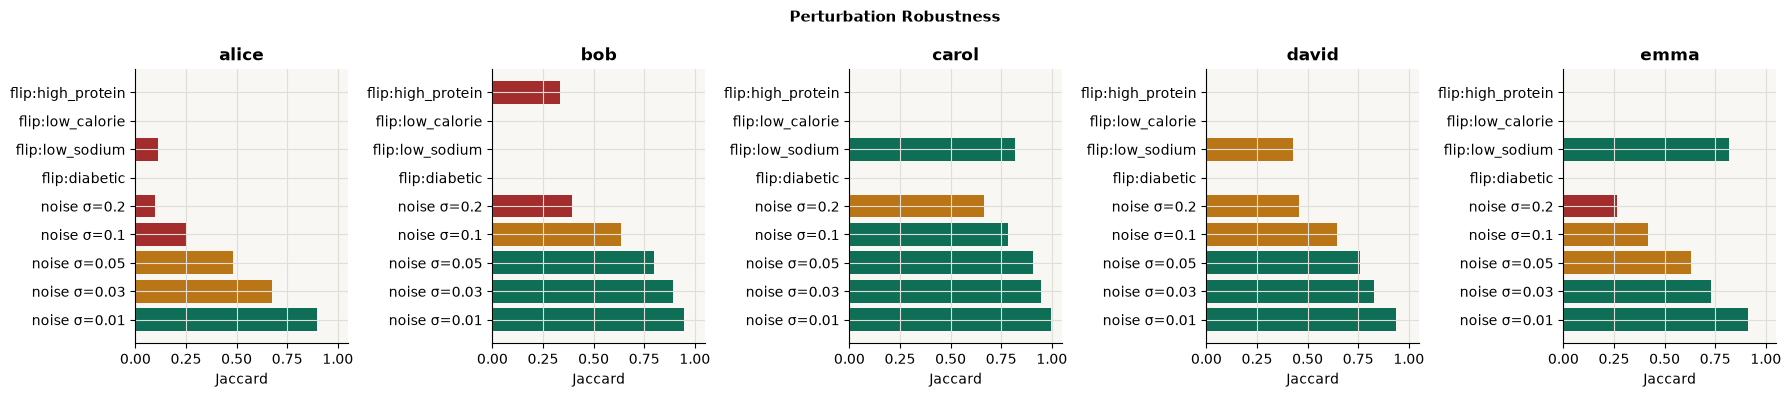

In [26]:
def jaccard(a,b): return len(a&b)/len(a|b) if a|b else 1.0
def topk_ids(uvec,k=10):
    sc=cosine_similarity(uvec.reshape(1,-1),R).flatten()
    return set(np.array(RECIPE_IDS)[np.argsort(sc)[::-1][:k]])

SIGMAS=[0.01,0.03,0.05,0.10,0.20]
FLAG_NAMES=['diabetic','low_sodium','low_calorie','high_protein']
rows=[]
for uname,info in DEMO_USERS.items():
    base=info['vec']; base_top=topk_ids(base)
    for sigma in SIGMAS:
        jvals=[]
        for _ in range(50):
            p=base.copy(); p[:6]+=np.random.normal(0,sigma,6)
            jvals.append(jaccard(base_top,topk_ids(np.clip(p,0,1))))
        rows.append({'user':uname,'type':f'noise σ={sigma}','mean_J':np.mean(jvals)})
    for fi,fname in enumerate(FLAG_NAMES):
        p=base.copy(); p[6+fi]=1-p[6+fi]
        rows.append({'user':uname,'type':f'flip:{fname}','mean_J':jaccard(base_top,topk_ids(p))})

df_perturb=pd.DataFrame(rows)
fig,axes=plt.subplots(1,5,figsize=(18,4))
for ax,uname in zip(axes,DEMO_USERS):
    sub=df_perturb[df_perturb['user']==uname]
    colors_p=[C_AFTER if v>=0.7 else C_FLAG if v>=0.4 else C_BEFORE for v in sub['mean_J']]
    ax.barh(sub['type'],sub['mean_J'],color=colors_p)
    ax.set_xlim(0,1.05); ax.set_title(uname,fontweight='bold'); ax.set_xlabel('Jaccard')
plt.suptitle('Perturbation Robustness',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/perturbation.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 11. Frontend
**Work Package: Frontend Application**

Run: `streamlit run app.py`


In [27]:
APP='''
import streamlit as st, pandas as pd, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px

st.set_page_config(page_title="Food Recommender",page_icon="\U0001f957",layout="wide")

FM=dict(calories=2000,protein_g=150,carbs_g=300,total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUM=list(FM.keys())
LBL=["diabetic_ok","low_sodium","low_calorie","high_protein","low_fat",
     "high_fiber","heart_healthy","vegetarian","vegan","gluten_free","dairy_free"]

@st.cache_data
def load():
    df = pd.read_csv("data/recipes_clean.csv")
    # Add missing label columns as zeros if not present
    for col in LBL:
        if col not in df.columns:
            df[col] = 0
    return df

df=load()
nut=df[NUM].copy()
for c,mx in FM.items(): nut[c]=nut[c].fillna(0)/mx
R=pd.concat([nut,df[LBL].fillna(0)],axis=1).values

st.title("\U0001f957 Health-Personalized Food Recommender")
st.caption(f"Food.com  |  {len(df):,} recipes")
c1,c2=st.columns([1,2])
with c1:
    st.subheader("Health Profile")
    cal =st.slider("Target calories",200,800,450,50)
    prot=st.slider("Target protein (g)",5,80,30,5)
    carb=st.slider("Max carbs (g)",10,250,120,10)
    fat =st.slider("Max fat (g)",5,80,35,5)
    sod =st.slider("Max sodium (mg)",100,2000,600,100)
    sug =st.slider("Max sugar (g)",0,50,15,5)
    st.divider()
    diab=st.checkbox("Type 2 Diabetes (carbs<=45g, sugar<=10g)")
    hyp =st.checkbox("Hypertension (sodium<=600mg)")
    veg =st.checkbox("Vegan")
    gf  =st.checkbox("Gluten-free")
    k   =st.slider("Recommendations",3,20,8)

with c2:
    n=np.array([cal/2000,prot/150,carb/300,fat/100,sod/5000,sug/200])
    l=np.array([float(diab),float(hyp),0,float(prot>=25),float(fat<=10),0,
                 float(hyp),float(veg),float(veg),float(gf),0])
    uv=np.clip(np.concatenate([n,l]),0,1)
    sc=cosine_similarity(uv.reshape(1,-1),R).flatten()
    res=df.copy(); res["score"]=sc
    res=res.sort_values("score",ascending=False)
    if diab: res=res[(res["carbs_g"]<=45)&(res["sugar_g"]<=10)]
    if hyp:  res=res[res["sodium_mg"]<=600]
    if veg  and "vegan" in res.columns:       res=res[res["vegan"]==1]
    if gf   and "gluten_free" in res.columns: res=res[res["gluten_free"]==1]
    recs=res.head(k).reset_index(drop=True)
    st.subheader(f"Top {k} Recommendations")
    if len(recs)==0:
        st.warning("No recipes match. Try relaxing some conditions.")
    else:
        fig=px.bar(recs,x="score",y="name",orientation="h",color="score",
                    color_continuous_scale="Teal",
                    hover_data=["calories","protein_g","carbs_g","sodium_mg"],
                    labels={"score":"Match","name":"Recipe"})
        fig.update_layout(yaxis={"categoryorder":"total ascending"},
                           height=420,showlegend=False,coloraxis_showscale=False)
        st.plotly_chart(fig,use_container_width=True)
        cols=[c for c in ["name","calories","protein_g","carbs_g",
                            "total_fat_g","sodium_mg","sugar_g","minutes"]
               if c in recs.columns]
        st.dataframe(recs[cols].round(1),use_container_width=True,hide_index=True)

with st.sidebar:
    st.subheader("Stats")
    st.metric("Recipes",f"{len(df):,}")
    for lbl in ["diabetic_ok","vegan","gluten_free","heart_healthy"]:
        if lbl in df.columns and df[lbl].sum() > 0:
            st.metric(lbl.replace("_"," ").title(),f"{int(df[lbl].sum()):,}")
'''
with open('app.py','w') as f: f.write(APP)
print('app.py written.  Run:  streamlit run app.py')

app.py written.  Run:  streamlit run app.py


In [28]:
import subprocess, threading, time

def run_streamlit():
    subprocess.run(['streamlit', 'run', 'app.py',
                    '--server.port', '8501',
                    '--server.headless', 'true'])

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()
time.sleep(3)
print('Streamlit running at: http://localhost:8501')

2026-07-02 01:12:54.384 Uvicorn server started on 0.0.0.0:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.178.89:8501
  External URL: http://94.139.29.124:8501

Streamlit running at: http://localhost:8501


---
## 12. Summary


In [29]:
import glob
print('='*60)
print('FOOD RECOMMENDER — PIPELINE SUMMARY')
print('='*60)
print(f'Recipes raw:          {len(df_recipes_raw):>8,}')
print(f'Recipes clean:        {len(df):>8,}  ({len(df)/len(df_recipes_raw):.1%} kept)')
print(f'Train interactions:   {len(df_train):>8,}')
print(f'Test  interactions:   {len(df_test):>8,}')
print(f'Active eval users:    {len(active_users):>8,}')
print(f'Recipe matrix R:      {str(R.shape):>8}  (nutrition + ingredient embeddings)')
print(f'Health labels:        {len(LABEL_COLS):>8}')
print()
print('=== Model Comparison (Precision@1) ===')
print(f'SVD: {np.mean(svd_prec[1]):.1%}  |  BPR: {np.mean(bpr_prec[1]):.1%}  '
      f'|  Selected: {ACTIVE_CF_MODEL.upper()}')
print()
print('Method 1 (Ranking) — selected model:')
sel_prec = bpr_prec if ACTIVE_CF_MODEL=='bpr' else svd_prec
sel_rec  = bpr_rec  if ACTIVE_CF_MODEL=='bpr' else svd_rec
for k in K_VALUES:
    print(f'  k={k:<3} Precision={np.mean(sel_prec[k]):.4f}  Recall={np.mean(sel_rec[k]):.4f}')
print()
print(f'Optuna best Hit@10:   {study.best_value:>8.1%}')
print(f'Best params:          {best}')
print()
plots=sorted(glob.glob('plots/*.png'))
print(f'Plots: {[os.path.basename(p) for p in plots]}')
print('='*60)
print('\n✅ All work packages complete:')
for wp,detail in [
    ('Data Scraping',      'USDA API — 2,000 recipes enriched'),
    ('Data Quality',       'Percentile cleaning + validation gates'),
    ('Data Annotation',    '11 health labels'),
    ('Vector Embeddings',  f'R={R.shape} (nutrition + ingredient text)'),
    ('Recommender System', f'SVD vs BPR compared, {ACTIVE_CF_MODEL.upper()} selected'),
    ('Evaluation',         'Precision@k/Recall@k — 2 methods, both models'),
    ('HP Tuning',          f'Optuna 30 trials → {study.best_value:.1%}'),
    ('Logging',            'W&B (WANDB_ENABLED=True to activate)'),
    ('Perturbation',       'Jaccard stability under noise + flag flips'),
    ('Frontend',           'streamlit run app.py'),
]:
    print(f'  ✅ {wp:<22} {detail}')


FOOD RECOMMENDER — PIPELINE SUMMARY
Recipes raw:           231,637
Recipes clean:         186,490  (80.5% kept)
Train interactions:    464,257
Test  interactions:    118,595
Active eval users:       6,772
Recipe matrix R:      (186490, 37)  (nutrition + ingredient embeddings)
Health labels:              11

=== Model Comparison (Precision@1) ===
SVD: 49.3%  |  BPR: 22.3%  |  Selected: SVD

Method 1 (Ranking) — selected model:
  k=1   Precision=0.4933  Recall=0.4933
  k=3   Precision=0.1644  Recall=0.4933
  k=5   Precision=0.0987  Recall=0.4933
  k=10  Precision=0.0493  Recall=0.4933

Optuna best Hit@10:      61.0%
Best params:          {'n_factors': 25, 'reg_all': 0.06917042404462198, 'lr_all': 0.013508682958815755}

Plots: ['annotation_labels.png', 'dataset_bias.png', 'eda_01_before_missing.png', 'eda_02_before_distributions.png', 'eda_03_before_consistency.png', 'eda_04_before_interactions.png', 'eda_05_cleaning_log.png', 'eda_06_after_missing.png', 'eda_07_before_after_distributions